# 07 — Neural Networks & Deep Learning
## Machine Learning in SPM Tutorial
*RMS AFM & SPM Meeting 2026*

## Goals

By the end of this notebook you will be able to:

- Understand what a **neural network** is, in plain terms — and how it differs from a linear model
- Train a small **multilayer perceptron (MLP)** and see it learn a *curved* decision boundary
- Read a **training-loss curve** and recognise under/over-fitting
- Understand conceptually where **CNNs** fit for SPM images, and when deep learning is (and isn't) worth it

## From linear models to neural networks

A linear model draws one straight boundary. A **neural network** stacks many simple units ("neurons"),
each computing a weighted sum followed by a non-linear **activation**. Stacking these in **layers** lets
the network bend and fold decision boundaries to fit complex patterns. Training adjusts the weights by
**backpropagation + gradient descent** to reduce a loss function.

You do not need to derive any of this to use it: in scikit-learn an MLP is a drop-in classifier. For
larger image models (CNNs) you would reach for PyTorch — the *concepts* are identical.

In [1]:
# --- Colab bootstrap: clone the repo & install deps when running on Google Colab ---
# (Does nothing when you run locally from the cloned repo.)
import os, sys
if 'google.colab' in sys.modules:
    if not os.path.exists('RMS-AFM-SPM-Meeting-2026'):
        !git clone -q https://github.com/Liambcollins/RMS-AFM-SPM-Meeting-2026.git
    %cd RMS-AFM-SPM-Meeting-2026/notebooks
    !pip -q install scikit-image >/dev/null 2>&1
    print('Colab setup complete.')

In [2]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
import numpy as np
import matplotlib.pyplot as plt
from viz.plotting import set_style
set_style()
print("Setup complete.")
from synthetic.generators import make_scan_quality_dataset

Setup complete.


## A neural net learns a curved boundary

We reuse the scan-quality data, but pick two features (`line_noise`, `drift`) whose classes overlap in a
**non-linear** way. Watch how the MLP bends its boundary where the straight logistic line cannot.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

_, X4, y, names = make_scan_quality_dataset(n_samples=700, random_state=1)
X = StandardScaler().fit_transform(X4[:, [0, 2]])   # line_noise vs drift
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

logreg = LogisticRegression().fit(X_tr, y_tr)
mlp = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu',
                    max_iter=2000, random_state=0).fit(X_tr, y_tr)
print(f"Logistic accuracy : {accuracy_score(y_te, logreg.predict(X_te)):.3f}")
print(f"MLP accuracy      : {accuracy_score(y_te, mlp.predict(X_te)):.3f}")

Logistic accuracy : 0.976
MLP accuracy      : 0.971


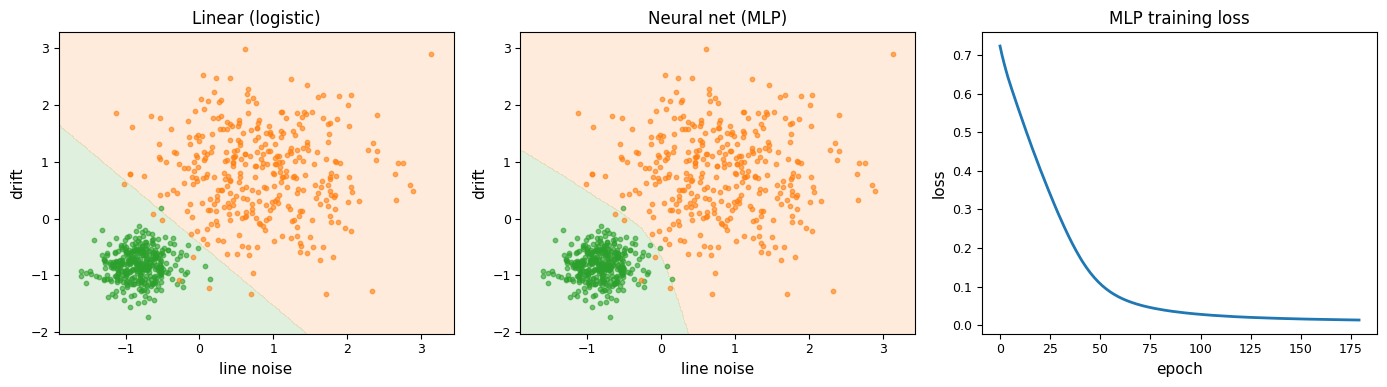

In [4]:
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-.3, X[:,0].max()+.3, 300),
                     np.linspace(X[:,1].min()-.3, X[:,1].max()+.3, 300))
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, model, name in [(ax[0], logreg, 'Linear (logistic)'),
                       (ax[1], mlp, 'Neural net (MLP)')]:
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    a.contourf(xx, yy, Z, alpha=0.15, levels=[-.5,.5,1.5], colors=['C2','C1'])
    for cls, color in [(0,'C2'), (1,'C1')]:
        m = y == cls
        a.scatter(X[m,0], X[m,1], s=10, c=color, alpha=0.6)
    a.set_title(name); a.set_xlabel('line noise'); a.set_ylabel('drift')
ax[2].plot(mlp.loss_curve_, 'C0', lw=2)
ax[2].set_title('MLP training loss'); ax[2].set_xlabel('epoch'); ax[2].set_ylabel('loss')
fig.tight_layout(); plt.show()

## What about images? Convolutional neural networks (CNNs)

The MLP above treats each feature independently. **SPM data is usually an image**, where *spatial
structure* matters. A **CNN** slides small learnable filters across the image to detect local patterns
(edges, domain walls, defects), then combines them hierarchically. CNNs power the heavy-duty SPM tasks:

- **Semantic segmentation** (e.g. U-Net) — label every pixel: domain A / domain B / wall / substrate
- **Denoising / super-resolution** — learn the mapping from noisy/fast scans to clean ones
- **Defect & anomaly detection** — flag tip crashes, contamination, streaking

These need a GPU and more labelled data, and are typically built in **PyTorch**. The workflow — split,
train, validate, watch the loss curve, guard against overfitting — is exactly what you just did.

### See a convolution in action

A CNN's core operation is the **convolution**: slide a small filter (a 3×3 grid of weights, the *kernel*)
across the image and, at every position, compute a weighted sum of the local pixels. Different kernels detect
different things — below we *hand-set* an edge filter and a smoothing filter, but the whole point of a CNN is that
it **learns** the kernels from data, and stacks them so later layers build edges → textures → objects.
Because the same kernel is reused everywhere (**weight sharing**), a CNN has few parameters and is naturally
aware of spatial structure — exactly what SPM images need.

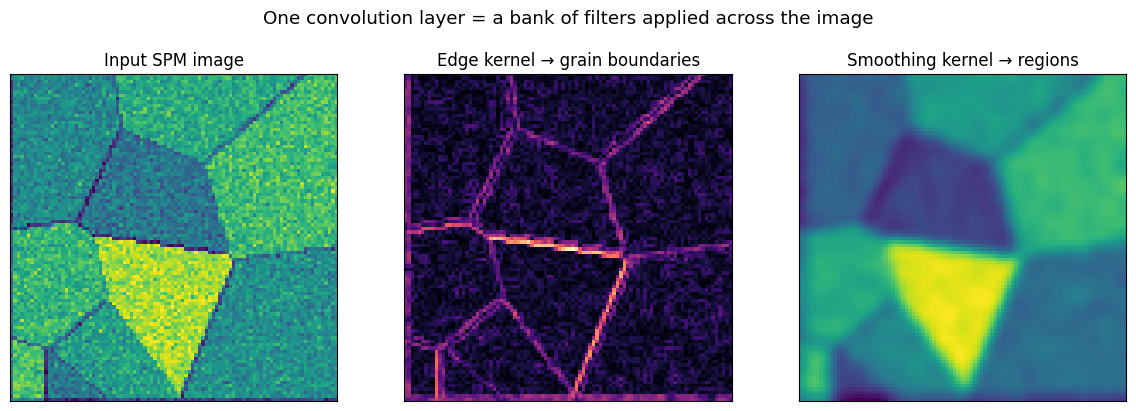

In [5]:
from scipy.ndimage import convolve, gaussian_filter
from synthetic.generators import make_grain_image

img = make_grain_image(size=96, n_grains=10, noise_level=0.08, random_state=3)

# Hand-set kernels (a CNN would LEARN filters like these):
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], float)
sobel_y = sobel_x.T
edges = np.hypot(convolve(img, sobel_x), convolve(img, sobel_y))   # edge / grain-boundary filter
smooth = gaussian_filter(img, 2.0)                                  # smoothing / blob filter

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img, cmap='viridis', origin='lower');  ax[0].set_title('Input SPM image')
ax[1].imshow(edges, cmap='magma', origin='lower');  ax[1].set_title('Edge kernel → grain boundaries')
ax[2].imshow(smooth, cmap='viridis', origin='lower'); ax[2].set_title('Smoothing kernel → regions')
for a in ax: a.set_xticks([]); a.set_yticks([])
fig.suptitle('One convolution layer = a bank of filters applied across the image', y=1.02)
fig.tight_layout(); plt.show()

## When is deep learning worth it?

| Use a neural net when… | Stick with classical ML when… |
|---|---|
| You have **lots** of data (1000s of images) | You have **few** samples (<a few hundred) |
| The signal is **spatial / sequential** (images, spectra) | Features are already tabular & informative |
| Hand-crafted features plateau | You need **interpretability** and speed |
| A GPU is available | You want a 5-minute baseline |

Deep learning is powerful but not automatic. For many SPM problems a well-chosen feature plus a random
forest beats a neural net trained on too little data.

## Takeaways

- A neural network = **stacked non-linear units**; it learns **curved** boundaries a linear model cannot.
- Train by minimising a **loss**; watch the **loss curve** to diagnose under/over-fitting.
- **CNNs** are the tool for SPM *images* — segmentation, denoising, defect detection — usually in PyTorch.
- More capacity needs **more data**. Match the model to the dataset, not the hype.